Shiva Pachade
Roll no=46  CSE(AI)  Div=D   Batch =2

Assignment 6
Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:
a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis
b. Bivariate analysis: Linear and logistic regression modeling
c. Multiple Regression analysis
d. Also compare the results of the above analysis for the two data sets. Dataset link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression, LogisticRegression

In [ ]:
df=pd.read_csv("/content/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape


(768, 9)

In [ ]:
diabetes = load_diabetes()
sklearn_df=pd.DataFrame(diabetes.data,columns=diabetes.feature_names)
sklearn_df['target']=diabetes.target
print("Sklearn Diabetes Shape:", sklearn_df.shape)

sklearn_df.head()

Sklearn Diabetes Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


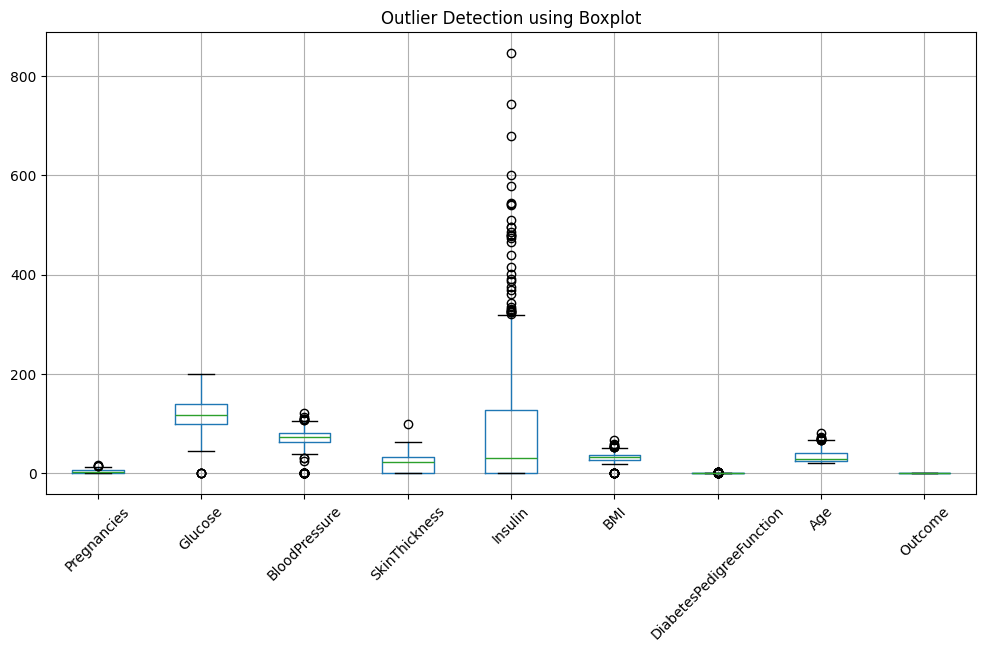

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df.boxplot()
plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_cols < (Q1 - 1.5 * IQR)) |
            (numeric_cols > (Q3 + 1.5 * IQR)))

print("Number of outliers in each column:")
print(outliers.sum())

Number of outliers in each column:
Pregnancies                  4
Glucose                      5
BloodPressure               45
SkinThickness                1
Insulin                     34
BMI                         19
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64


In [ ]:
df_clean = df[~((numeric_cols < (Q1 - 1.5 * IQR)) |
                 (numeric_cols > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (768, 9)
After Removing Outliers: (639, 9)


Univaraite analysis

In [ ]:
def univariate_analysis(df):
    result = pd.DataFrame({
        "Mean": df.mean(),
        "Median": df.median(),
        "Mode": df.mode().iloc[0],
        "Variance": df.var(),
        "Std Dev": df.std(),
        "Skewness": df.skew(),
        "Kurtosis": df.kurt()
    })
    return result


In [ ]:
print("Univariate Analysis for Diabetes Dataset:")
print(univariate_analysis(df))
print("\nUnivariate Analysis - Sklearn Diabetes Dataset")
print(univariate_analysis(sklearn_df))

Univariate Analysis for Diabetes Dataset:
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.180157  
S

In [ ]:
print(df['Outcome'].value_counts())


Outcome
0    500
1    268
Name: count, dtype: int64


Linear regression

In [ ]:
X = sklearn_df[['bmi']]
y = sklearn_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Linear Regression Results (Sklearn Dataset)
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032


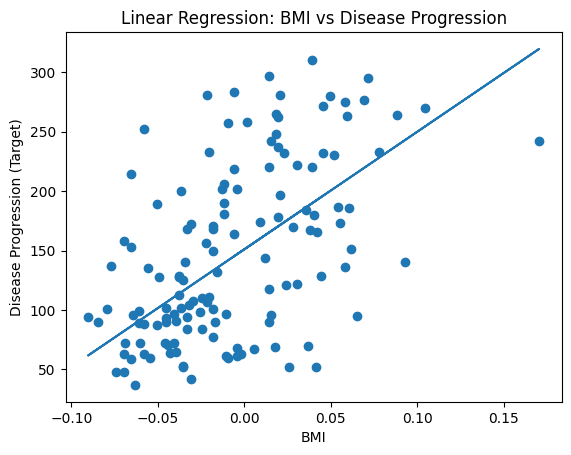

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("BMI")
plt.ylabel("Disease Progression (Target)")
plt.title("Linear Regression: BMI vs Disease Progression")

plt.show()

Logistic Regression

In [ ]:
X = df[['Glucose']]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Logistic Regression Results (Pima Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Results (Pima Dataset)
Accuracy: 0.7229437229437229
Confusion Matrix:
 [[128  23]
 [ 41  39]]


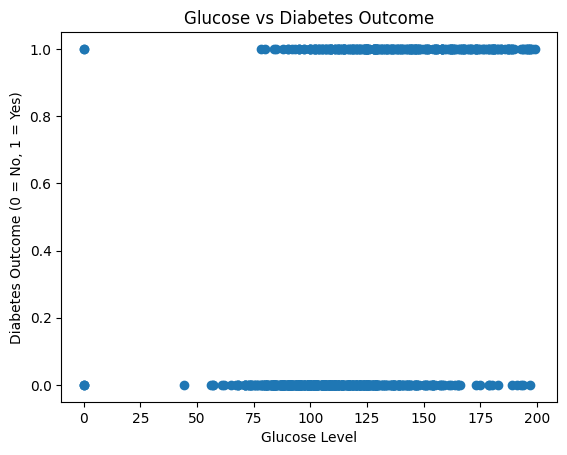

In [ ]:
plt.figure()

plt.scatter(df['Glucose'], df['Outcome'])

plt.xlabel("Glucose Level")
plt.ylabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.title("Glucose vs Diabetes Outcome")

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


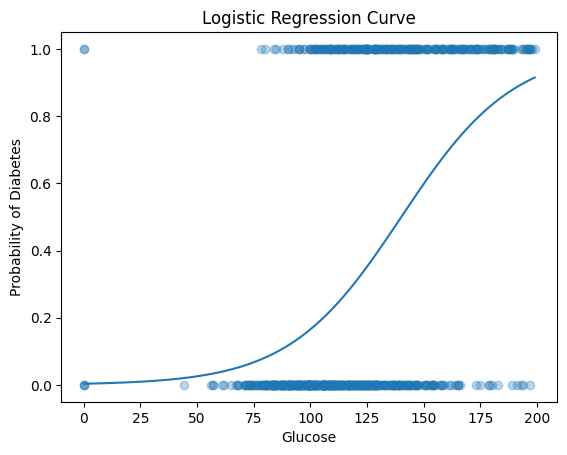

In [ ]:
import numpy as np

X_range = np.linspace(df['Glucose'].min(),
                      df['Glucose'].max(), 300).reshape(-1,1)

y_prob = log_reg.predict_proba(X_range)[:,1]

plt.figure()
plt.scatter(df['Glucose'], df['Outcome'], alpha=0.3)
plt.plot(X_range, y_prob)   # logistic curve
plt.xlabel("Glucose")
plt.ylabel("Probability of Diabetes")
plt.title("Logistic Regression Curve")
plt.show()

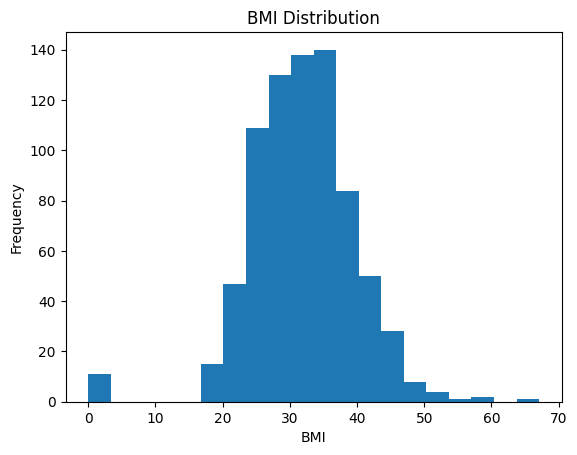

In [ ]:
plt.figure()
plt.hist(df['BMI'], bins=20)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("BMI Distribution")

plt.show()